In [3]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
import pickle
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# 1️. Load balanced dataset
# ------------------------
df = pd.read_csv("addbalanced_data.csv")  # your balanced dataset file
df = df[['Review', 'Rating']]

print(df['Rating'].value_counts())


Rating
1.0    50000
2.0    50000
3.0    50000
4.0    50000
5.0    50000
Name: count, dtype: int64


In [4]:
# 2️. Encode labels
# ------------------------
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Rating'])
num_labels = len(label_encoder.classes_)

In [5]:
# 3️. Train-Test Split
# ------------------------
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [6]:
# 4️. Tokenization & Padding
# ------------------------
max_vocab_size = 10000
max_seq_len = 128

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=max_seq_len, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_seq_len, padding='post', truncating='post')

In [7]:
# 5️. TensorFlow Datasets
# ------------------------
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((train_padded, train_labels)).shuffle(1000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((test_padded, test_labels)).batch(batch_size)

In [8]:
# 6️. Build LSTM Model
# ------------------------
embedding_dim = 128
model_a = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_labels, activation='softmax')
])

In [9]:
model_a.summary()

model_a.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 128, 128)          1280000   
                                                                 
 bidirectional (Bidirectiona  (None, 128, 128)         98816     
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 3

In [10]:
# 7️. Compute Class Weights (optional for balanced data)
# ------------------------
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = {i: class_weights_values[i] for i in range(num_labels)}
print("Class weights:", class_weights)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


In [11]:
# 8️. Train Model
# ------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model_a.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
6250/6250 [==============================] - 798s 127ms/step - loss: 1.1361 - accuracy: 0.4994 - val_loss: 1.0720 - val_accuracy: 0.5253
Epoch 2/20
6250/6250 [==============================] - 786s 126ms/step - loss: 1.0481 - accuracy: 0.5408 - val_loss: 1.0653 - val_accuracy: 0.5274
Epoch 3/20
6250/6250 [==============================] - 795s 127ms/step - loss: 0.9982 - accuracy: 0.5658 - val_loss: 1.0876 - val_accuracy: 0.5298
Epoch 4/20
6250/6250 [==============================] - 804s 129ms/step - loss: 0.9478 - accuracy: 0.5906 - val_loss: 1.1353 - val_accuracy: 0.5247
Epoch 5/20
6250/6250 [==============================] - 824s 132ms/step - loss: 0.8929 - accuracy: 0.6177 - val_loss: 1.2349 - val_accuracy: 0.5169


In [12]:
# 9️. Save Model in TF Format (for safe loading later)
# ------------------------
model_a.save("lstm_balanced_review_model1")  # TF SavedModel format ✅

INFO:tensorflow:Assets written to: lstm_balanced_review_model1\assets


INFO:tensorflow:Assets written to: lstm_balanced_review_model1\assets


In [13]:
# . Save Tokenizer & Label Encoder
# ------------------------
with open('tokenizer_lstm_balanced.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

joblib.dump(label_encoder, "label_encoder_lstm_balanced.pkl")

print("✅ Model A trained & saved successfully!")

✅ Model A trained & saved successfully!


In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Load balanced training dataset
df = pd.read_csv("addbalanced_data.csv")

# Split into train/test (e.g., 80/20)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Rating"])

# Tokenizer
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["Review"].astype(str).tolist())

# Label encoder
label_encoder = LabelEncoder()
label_encoder.fit(train_df["Rating"])

# Prepare test set
max_len = 128
X_test_seq = tokenizer.texts_to_sequences(test_df["Review"].astype(str).tolist())
X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(X_test_seq, maxlen=max_len, padding='post')
y_test = label_encoder.transform(test_df["Rating"])

# Load model
model_a = tf.keras.models.load_model("lstm_balanced_review_model1")

# Predict & evaluate
y_pred_probs = model_a.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)


In [2]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Predictions already computed...
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:")
target_names = [str(cls) for cls in label_encoder.classes_]
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.5274

Classification Report:
              precision    recall  f1-score   support

         1.0       0.60      0.60      0.60     10000
         2.0       0.42      0.51      0.46     10000
         3.0       0.44      0.35      0.39     10000
         4.0       0.52      0.42      0.47     10000
         5.0       0.65      0.76      0.70     10000

    accuracy                           0.53     50000
   macro avg       0.52      0.53      0.52     50000
weighted avg       0.52      0.53      0.52     50000



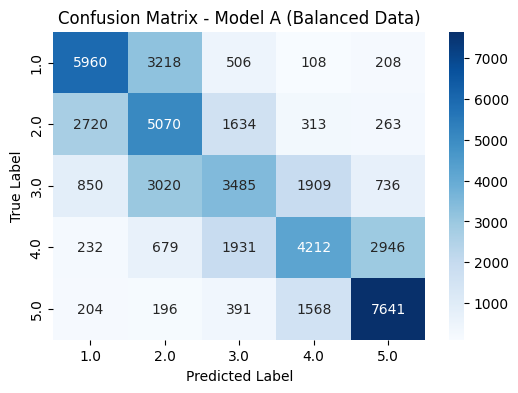

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Model A (Balanced Data)")
plt.show()